In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
from src.config import *
from src.utils import set_seed
from src.data_loader import load_dataset
from src.preprocessing import preprocess_pipeline
from src.model_tabnet import (
    train_pipeline,
    predict,
    load_saved_model
)
from src.evaluation import regression_metrics

from src.visualization import (
    plot_prediction,
    plot_residual
)

In [3]:
df = load_dataset()

df.head()

[2026-07-06 00:48:02] Loading dataset : C:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\dataset\heartv1.csv
[2026-07-06 00:48:02] Dataset loaded successfully.


,sex,age,cp,resting_BP,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Max Heart Rate Reserve,Heart Disease Risk Score,target
0,male,65,0,130,254,0,0,147,0,1.4,1,1,3,10,11.44,0
1,male,53,0,140,261,0,0,186,1,0.0,2,0,2,-17,13.51,1
2,male,50,0,122,222,0,0,186,0,0.0,2,0,2,-14,9.46,1
3,female,47,1,112,160,0,1,138,0,0.0,1,0,2,37,8.34,1
4,male,47,0,142,309,0,0,147,1,0.0,1,3,3,28,13.43,0


In [4]:
data = preprocess_pipeline(df)

[2026-07-06 00:48:02] ============================================================
[2026-07-06 00:48:02] START PREPROCESSING
[2026-07-06 00:48:02] ============================================================
[2026-07-06 00:48:02] Duplicate removed : 723
[2026-07-06 00:48:02] Current rows      : 312
[2026-07-06 00:48:02] Missing values : 0
[2026-07-06 00:48:02] Rows removed : 0
[2026-07-06 00:48:02] Categorical features encoded.
[2026-07-06 00:48:02] Feature shape : (312, 14)
[2026-07-06 00:48:02] Target shape  : (312,)
[2026-07-06 00:48:02] Feature columns saved.
[2026-07-06 00:48:02] Dataset split completed.
[2026-07-06 00:48:02] Train      : 218
[2026-07-06 00:48:02] Validation : 47
[2026-07-06 00:48:02] Test       : 47
[2026-07-06 00:48:02] Scaler saved successfully.
[2026-07-06 00:48:02] Processed datasets saved successfully.
[2026-07-06 00:48:02] ============================================================
[2026-07-06 00:48:02] PREPROCESSING FINISHED
[2026-07-06 00:48:02] ========

In [6]:
model, history = train_pipeline(
    data["X_train"],
    data["y_train"],
    data["X_valid"],
    data["y_valid"]
)

[2026-07-06 00:48:02] ============================================================
[2026-07-06 00:48:02] START TABNET TRAINING
[2026-07-06 00:48:02] ============================================================
[2026-07-06 00:48:02] TabNet model created.
[2026-07-06 00:48:02] Starting TabNet training...


c:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\.venv311\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 124.84167| val_0_rmse: 11.28962|  0:00:00s
epoch 1  | loss: 123.05634| val_0_rmse: 11.52793|  0:00:00s
epoch 2  | loss: 113.83969| val_0_rmse: 11.55468|  0:00:00s
epoch 3  | loss: 110.78033| val_0_rmse: 11.4318 |  0:00:00s
epoch 4  | loss: 105.6144| val_0_rmse: 11.25853|  0:00:01s
epoch 5  | loss: 98.19267| val_0_rmse: 11.07842|  0:00:01s
epoch 6  | loss: 97.9255 | val_0_rmse: 10.87608|  0:00:01s
epoch 7  | loss: 93.91975| val_0_rmse: 10.65838|  0:00:01s
epoch 8  | loss: 90.84148| val_0_rmse: 10.42586|  0:00:01s
epoch 9  | loss: 82.99202| val_0_rmse: 10.17722|  0:00:02s
epoch 10 | loss: 78.88674| val_0_rmse: 9.96284 |  0:00:02s
epoch 11 | loss: 74.90093| val_0_rmse: 9.79827 |  0:00:02s
epoch 12 | loss: 73.24459| val_0_rmse: 9.63745 |  0:00:02s
epoch 13 | loss: 70.4472 | val_0_rmse: 9.42645 |  0:00:02s
epoch 14 | loss: 67.16901| val_0_rmse: 9.20119 |  0:00:03s
epoch 15 | loss: 60.78738| val_0_rmse: 8.98578 |  0:00:03s
epoch 16 | loss: 60.13701| val_0_rmse: 8.814   |  0:

c:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\.venv311\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [7]:
prediction = predict(
    model,
    data["X_test"]
)

prediction[:10]

array([13.418713,  9.898326, 10.563833, 14.288711, 13.135298, 11.415545,
        8.809593, 13.764371,  9.567802, 12.693787], dtype=float32)

In [8]:
metrics = regression_metrics(
    data["y_test"],
    prediction
)

metrics

[2026-07-06 00:48:37] Evaluation completed.


,MAE,RMSE,MAPE,R2
MLP,0.539552,0.640373,4.617139,0.923429


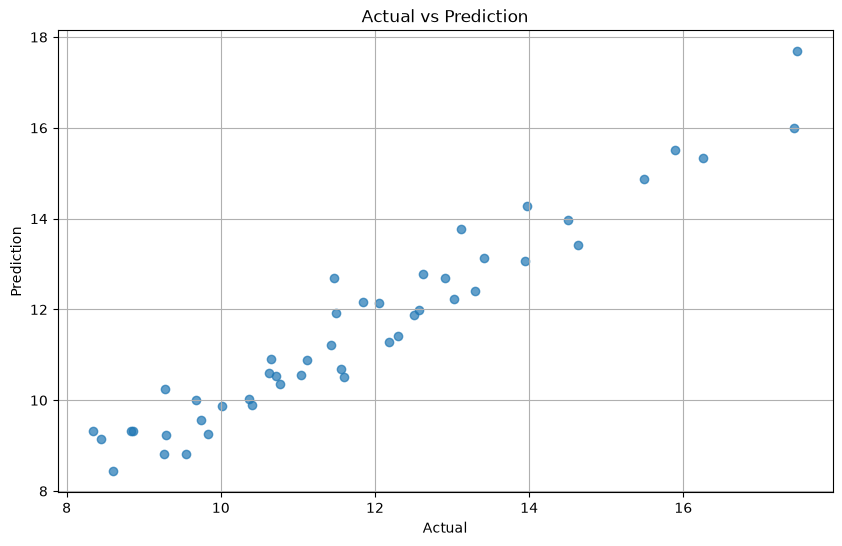

In [9]:
plot_prediction(
    data["y_test"],
    prediction
)

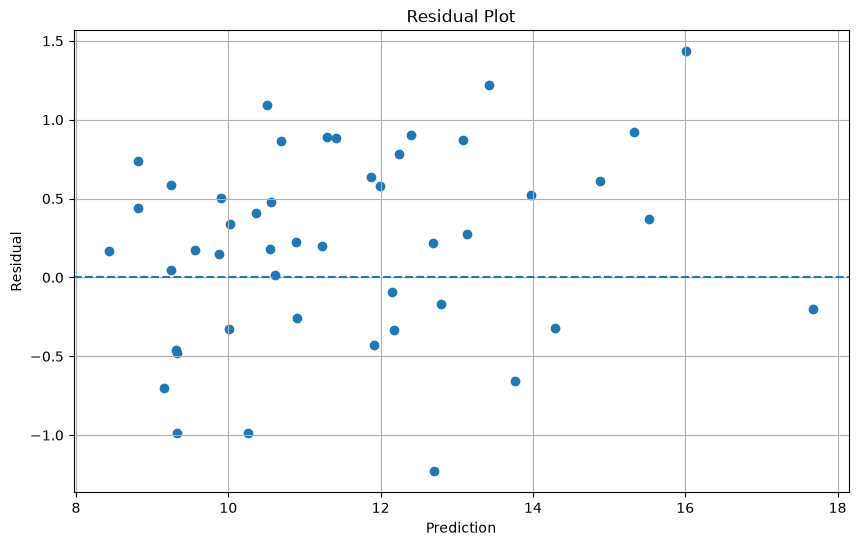

In [11]:
plot_residual(
    data["y_test"],
    prediction
)